# Rapport de projet – Analyse de données et apprentissage automatique

**Réalisé par :** Oumayma MEKTANE

**Groupe :** B3 DEV. DATA & AI (Spring 2026)

**Année :** 2025–2026

## Objectif général

Ce projet a pour objectif de conduire un pipeline complet d’analyse de données, depuis le choix du dataset jusqu’à l’application d’un ou plusieurs modèles de machine learning. Vous travaillerez en groupe (3 à 4 étudiants) et documenterez toutes les étapes de votre démarche dans ce rapport. Chaque section doit être remplie de manière rigoureuse, avec des explications claires et des justifications. Le rapport servira à l’évaluation finale du module pour **40 % de la note finale**.

# Partie 1 – Définition du sujet et choix du dataset

## 1.1 Thématique générale

**Domaine choisi :**  
Le projet s’inscrit dans le domaine de l’économie et de la finance, plus précisément dans l’analyse du risque de crédit.

**Problématique :**  
L’objectif de ce projet est d’analyser les caractéristiques financières et personnelles des emprunteurs afin de prédire le risque de défaut de paiement.  
La question centrale étudiée est la suivante :  
**Quels facteurs influencent le défaut de paiement et dans quelle mesure peut-on anticiper ce risque à partir des données disponibles ?**

**Intérêt du sujet :**  
L’évaluation du risque de crédit constitue un enjeu majeur pour les établissements financiers. Une mauvaise estimation du risque peut entraîner des pertes économiques importantes, tandis qu’une estimation trop stricte peut conduire à refuser l’accès au crédit à des emprunteurs pourtant solvables.

**Intérêt pour la société et les entreprises :**  
Ce sujet présente un intérêt à la fois économique et sociétal. Il permet d’améliorer la stabilité financière des institutions, de favoriser des décisions d’octroi de crédit plus justes et cohérentes, de limiter le surendettement des ménages et d’optimiser les politiques de gestion du risque.

## 1.2 Recherche et sélection du dataset

### Informations générales sur le dataset

**Nom du dataset :** Credit Risk Dataset  

**Source et lien d’accès :** Kaggle  https://www.kaggle.com/datasets/laotse/credit-risk-dataset

**Auteur / organisation :** Communauté Kaggle  

**Taille :** 32 581 lignes et 12 colonnes  

**Format du fichier :** CSV  

### Vérification de la qualité

Le dataset contient un volume de données suffisant pour réaliser une analyse statistique approfondie et entraîner des modèles de machine learning.  
Les variables sont clairement nommées et compréhensibles.  
Il comporte une variable cible binaire (`loan_status`) permettant d’identifier les situations de défaut de paiement.  
Certaines valeurs manquantes sont présentes, mais leur proportion reste limitée et traitable.

### Justification du choix

Ce dataset a été choisi car il est directement adapté à la problématique du risque de crédit. Il inclut des variables financières importantes (revenu, montant du prêt, taux d’intérêt), des informations sur les emprunteurs (âge, ancienneté d’emploi, historique de crédit) ainsi qu’une variable cible liée au défaut de paiement.

**Limites ou difficultés potentielles :** 

Le dataset présente des valeurs manquantes sur certaines variables, notamment l’ancienneté d’emploi et le taux d’intérêt.  
De plus, les données étant issues d’une source unique et anonymisées, des biais d’échantillonnage peuvent exister.

## 1.3 Validation du dataset

| Critère        | Question                                                                 | Réponse (Oui/Non) | Détail / Justification |
|---------------|--------------------------------------------------------------------------|-------------------|------------------------|
| Pertinence    | Le dataset permet-il de répondre à votre question de départ ?            | Oui               | Présence d’une variable cible liée au défaut de paiement |
| Clarté        | Les variables sont-elles bien nommées et compréhensibles ?               | Oui               | Noms explicites et cohérents avec le domaine du crédit |
| Propreté      | Les données semblent-elles utilisables sans nettoyage majeur ?           | Oui               | Valeurs manquantes présentes mais en proportion modérée |
| Taille        | Le dataset est-il d’une taille adaptée à votre analyse ?                 | Oui               | 32 581 observations, suffisant pour l’EDA et la modélisation |
| Accessibilité | Le format est-il compatible avec Python (CSV, XLSX) ?                    | Oui               | Format CSV directement lisible avec pandas |
| Actualité     | Les données sont-elles récentes ou encore valides ?                      | Oui               | Données réalistes et pertinentes pour une étude du risque |

# Partie 2 – Exploration initiale des données

## 2.1 Chargement et aperçu du dataset

In [ ]:
import pandas as pd

PATH = 'credit_risk_dataset.csv'

df = pd.read_csv(PATH)

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


**Dimensions du dataset :**

On affiche le nombre de lignes (observations) et de colonnes (variables).

In [4]:
df.shape

(32581, 12)

**Variables :** nom et type

On liste les variables et leurs types pandas (numérique / catégorielle).

In [5]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

**Signification de chaque variable :**

- **`person_age`** : âge du client (années)
- **`person_income`** : revenu annuel du client
- **`person_home_ownership`** : statut de logement (RENT / OWN / MORTGAGE / OTHER)
- **`person_emp_length`** : ancienneté professionnelle (années)
- **`loan_intent`** : objectif du prêt (EDUCATION, MEDICAL, PERSONAL, etc.)
- **`loan_grade`** : note de crédit du prêt (A → G, ordre de risque croissant)
- **`loan_amnt`** : montant du prêt
- **`loan_int_rate`** : taux d’intérêt du prêt
- **`loan_status`** : statut du prêt (cible) — **0 = non défaut, 1 = défaut**
- **`loan_percent_income`** : part du revenu consacrée au prêt (ratio)
- **`cb_person_default_on_file`** : défaut antérieur enregistré (Y / N)
- **`cb_person_cred_hist_length`** : durée de l’historique de crédit (années)

**Valeurs manquantes et incohérences :**

On calcule le nombre de valeurs manquantes par variable, puis le pourcentage par rapport au total.

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_%': missing_pct
}).sort_values('missing_count', ascending=False)

missing_report

,missing_count,missing_%
loan_int_rate,3116,9.56
person_emp_length,895,2.75
person_income,0,0.00
person_age,0,0.00
person_home_ownership,0,0.00
loan_intent,0,0.00
loan_grade,0,0.00
loan_amnt,0,0.00
loan_status,0,0.00
loan_percent_income,0,0.00


**Résultat attendu :**
- `person_emp_length` : **895** valeurs manquantes (~**2,75 %**)
- `loan_int_rate` : **3 116** valeurs manquantes (~**9,56 %**)
- Toutes les autres variables : **0** valeur manquante

**Contrôles simples d’incohérences :**
On vérifie des contraintes de bon sens (valeurs négatives, âges irréalistes, etc.).

In [7]:
# Contrôles de cohérence
checks = {
    'age_negative': (df['person_age'] < 0).sum(),
    'income_negative': (df['person_income'] < 0).sum(),
    'loan_amnt_negative': (df['loan_amnt'] < 0).sum(),
    'int_rate_negative': (df['loan_int_rate'] < 0).sum(),
    'emp_length_negative': (df['person_emp_length'] < 0).sum(),
    'loan_percent_income_negative': (df['loan_percent_income'] < 0).sum(),
    'cred_hist_negative': (df['cb_person_cred_hist_length'] < 0).sum(),
}

pd.Series(checks)

age_negative                    0
income_negative                 0
loan_amnt_negative              0
int_rate_negative               0
emp_length_negative             0
loan_percent_income_negative    0
cred_hist_negative              0
dtype: int64

**Interprétation :** si ces compteurs sont à 0, il n’y a pas d’incohérence évidente sur ces règles.
Les valeurs extrêmes (outliers) peuvent exister sans être des erreurs : elles seront traitées lors de l’analyse exploratoire.

## 2.2 Typologie des données

Classement des variables selon leur type (quantitative continue/discrète, qualitative nominale/ordinale, etc.).

#### Variables quantitatives continues
- `person_income`
- `person_emp_length`
- `loan_amnt`
- `loan_int_rate`
- `loan_percent_income`

#### Variables quantitatives discrètes
- `person_age`
- `cb_person_cred_hist_length`
- `loan_status` (binaire 0/1)

#### Variables qualitatives nominales
- `person_home_ownership`
- `loan_intent`
- `cb_person_default_on_file`

#### Variables qualitatives ordinales
- `loan_grade` (A → G)

#### Variables temporelles
- Aucune variable de type date/année n’est présente dans ce dataset.

#### Autres
- Aucune donnée non structurée (texte libre, image, etc.).


### Variables les plus importantes pour l’analyse (justification)
Dans une analyse de risque de crédit, les variables les plus importantes sont généralement celles qui reflètent :
1) la **capacité de remboursement**
2) le **profil de risque du prêt**
3) l’**historique de crédit**
4) la **stabilité**

#### 1) Capacité de remboursement
- `person_income`
- `loan_percent_income`
- `loan_amnt`

#### 2) Risque du prêt
- `loan_int_rate`
- `loan_grade`
- `loan_intent`

#### 3) Historique de crédit
- `cb_person_default_on_file`
- `cb_person_cred_hist_length`

#### 4) Stabilité / profil socio-démographique
- `person_emp_length`
- `person_home_ownership`
- `person_age`

On peut afficher des statistiques descriptives rapides :

In [8]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83


### Variable cible
La variable cible (à prédire / expliquer) est **`loan_status`**.
- `0` : non défaut
- `1` : défaut

On peut vérifier la distribution de la cible :

In [9]:
df['loan_status'].value_counts(dropna=False).to_frame('count')

# En pourcentage
(df['loan_status'].value_counts(normalize=True) * 100).round(2).to_frame('pct')

,pct
loan_status,
0,78.18
1,21.82


# Partie 3 – Nettoyage et préparation du dataset

## 3.1 Gestion des valeurs manquantes

In [10]:
# Valeurs manquantes : nombre + pourcentage
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_%': missing_pct
}).sort_values('missing_count', ascending=False)

missing_report

,missing_count,missing_%
loan_int_rate,3116,9.56
person_emp_length,895,2.75
person_income,0,0.00
person_age,0,0.00
person_home_ownership,0,0.00
loan_intent,0,0.00
loan_grade,0,0.00
loan_amnt,0,0.00
loan_status,0,0.00
loan_percent_income,0,0.00


**Interprétation :**
Les valeurs manquantes concernent uniquement deux variables :

- `person_emp_length` : 895 valeurs manquantes (~2,75 %)
- `loan_int_rate` : 3 116 valeurs manquantes (~9,56 %)

Toutes les autres variables ne présentent aucune valeur manquante.

**Stratégie appliquée :**  
Imputation par la médiane pour les variables numériques.

**Justification :**  
La proportion de valeurs manquantes est modérée ; supprimer les lignes ferait perdre de l’information.  
La médiane est robuste face aux valeurs extrêmes, fréquentes dans les données financières.

In [11]:
# Imputation par la médiane
df_clean = df.copy()

df_clean["person_emp_length"] = df_clean["person_emp_length"].fillna(
    df_clean["person_emp_length"].median()
)

df_clean["loan_int_rate"] = df_clean["loan_int_rate"].fillna(
    df_clean["loan_int_rate"].median()
)

# Vérification
df_clean.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

## 3.2 Détection et traitement des doublons

In [12]:
# Détection des doublons
df_clean.duplicated().sum()

np.int64(165)

**Interprétation :**
165 doublons ont été détectés avant traitement.

In [13]:
# Suppression des doublons
df_clean = df_clean.drop_duplicates()

df_clean.shape

(32416, 12)

Ils ont été supprimés afin d’éviter une sur-représentation artificielle de certaines observations, pouvant biaiser les statistiques et les modèles.

## 3.3 Détection des valeurs aberrantes

In [14]:
import numpy as np

# Colonnes numériques (incluant la cible pour l'instant)
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

# Détection via IQR
outlier_summary = []

for col in numeric_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    
    outliers = ((df_clean[col] < low) | (df_clean[col] > high)).sum()
    outlier_summary.append((col, int(outliers), low, high))

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["variable", "n_outliers", "low_bound", "high_bound"]
).sort_values("n_outliers", ascending=False)

outlier_df


,variable,n_outliers,low_bound,high_bound
5,loan_status,7089,0.00,0.00
3,loan_amnt,1679,-5875.00,23125.00
0,person_age,1491,12.50,40.50
1,person_income,1478,-22472.00,140232.00
7,cb_person_cred_hist_length,1139,-4.50,15.50
2,person_emp_length,852,-5.50,14.50
6,loan_percent_income,650,-0.12,0.44
4,loan_int_rate,70,1.56,20.04


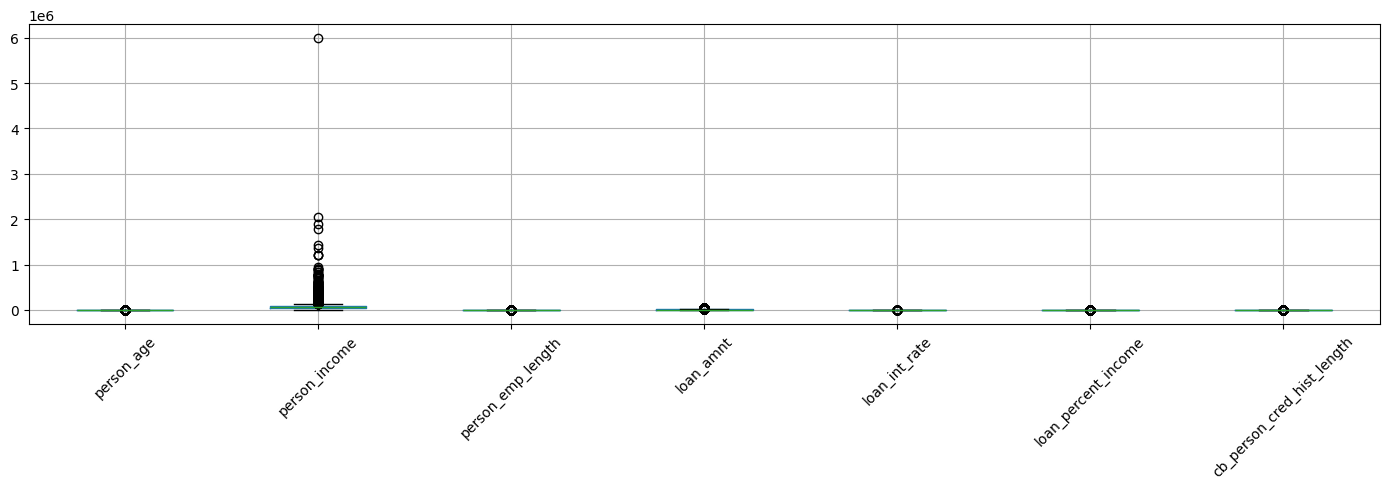

In [15]:
import matplotlib.pyplot as plt

numeric_cols_no_target = [col for col in numeric_cols if col != "loan_status"]

plt.figure(figsize=(14, 5))
df_clean[numeric_cols_no_target].boxplot(rot=45)
plt.tight_layout()
plt.show()

La méthode IQR met en évidence des valeurs extrêmes sur plusieurs variables numériques (revenu, montant de prêt, taux d’intérêt, ratio prêt/revenu).  
Dans un contexte de crédit, ces valeurs peuvent correspondre à des profils rares mais réalistes (revenus élevés, prêts importants).

**Décision :**  
Les valeurs extrêmes ont été conservées, car elles peuvent contenir une information pertinente pour la modélisation. Une limitation (winsorisation/capping) pourrait être testée ultérieurement à titre comparatif.

## 3.4 Encodage et mise à l’échelle des variables

Certaines variables doivent être converties en numériques avant d’être utilisées dans un modèle.

Dans cette section, on prépare les données en :
- standardisant les variables numériques (centrage-réduction) ;
- encodant les variables catégorielles par One-Hot Encoding.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Séparation features / cible
X = df_clean.drop(columns=["loan_status"]) # df_clean doit exister (après nettoyage)
y = df_clean["loan_status"]


# Identification automatique des colonnes numériques et catégorielles
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


numeric_features, categorical_features

/tmp/ipykernel_2187/260202604.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


(['person_age',
  'person_income',
  'person_emp_length',
  'loan_amnt',
  'loan_int_rate',
  'loan_percent_income',
  'cb_person_cred_hist_length'],
 ['person_home_ownership',
  'loan_intent',
  'loan_grade',
  'cb_person_default_on_file'])

**Variables concernées :**

- **Variables numériques (standardisées)** : `person_age`, `person_income`, `person_emp_length`, `loan_amnt`, `loan_int_rate`, `loan_percent_income`, `cb_person_cred_hist_length`
- **Variables catégorielles (encodées)** : `person_home_ownership`, `loan_intent`, `loan_grade`, `cb_person_default_on_file`

In [17]:
# Construction du prétraitement
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### Aperçu après encodage

Afin de visualiser concrètement le résultat du prétraitement, on applique la transformation à `X` puis on reconstruit un DataFrame avec les noms des nouvelles colonnes.

In [18]:
# Fit + transformation
X_encoded = preprocessor.fit_transform(X)

# Récupération des noms de colonnes One-Hot
num_features_out = numeric_features
cat_features_out = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)

feature_names = list(num_features_out) + list(cat_features_out)

# Conversion en DataFrame lisible (attention mémoire si dataset très grand)
X_encoded_df = pd.DataFrame(
X_encoded.toarray() if hasattr(X_encoded, "toarray") else X_encoded,
columns=feature_names
)

# Aperçu
X_encoded_df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
0,-0.904471,-0.114354,28.904903,4.018287,1.623527,3.929865,-0.692614,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,-1.061852,-0.910941,0.056504,-1.359219,0.040655,-0.657707,-0.938982,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.432327,-0.910941,-0.921408,-0.647491,0.601796,3.742617,-0.692614,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.747089,-0.009540,-0.187974,4.018287,1.367283,3.368121,-0.938982,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.589708,-0.188530,0.789938,4.018287,1.055898,3.555369,-0.446246,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [19]:
# Dimensions avant / après encodage
print("Dimensions avant encodage :", X.shape)
print("Dimensions après encodage :", X_encoded_df.shape)

Dimensions avant encodage : (32416, 11)
Dimensions après encodage : (32416, 26)


**Interprétation :**

Après application du prétraitement, toutes les variables sont numériques, ce qui permet l’entraînement des modèles de machine learning.

- Les variables numériques ont été **standardisées** : elles sont centrées autour de 0 avec une variance proche de 1.  
  Cela évite qu’une variable à grande échelle (ex. revenu, montant du prêt) domine l’apprentissage.

- Les variables catégorielles ont été transformées via **One-Hot Encoding** : chaque modalité devient une colonne binaire (0/1).  
  Bien que `loan_grade` possède un ordre naturel (A → G), le One-Hot Encoding permet de ne pas imposer une relation linéaire artificielle entre les grades.

**Pourquoi standardiser :**  
Certains modèles (régression logistique, SVM, kNN) sont sensibles à l’échelle des variables. Sans standardisation, les variables ayant de grandes valeurs peuvent biaiser l’entraînement et la performance du modèle.

Le dataset est désormais nettoyé et prêt pour l’analyse exploratoire et la modélisation.

# Partie 4 – Analyse exploratoire et visualisations

Réalisez une première exploration visuelle pour mieux comprendre les relations entre les variables.

In [20]:
# Corrélation entre variables numériques
corr = df_clean.select_dtypes(include=["int64", "float64"]).corr()

corr

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173293,0.161342,0.050680,0.011074,-0.022698,-0.042300,0.859215
person_income,0.173293,1.000000,0.134791,0.265947,0.000826,-0.145005,-0.254472,0.117614
person_emp_length,0.161342,0.134791,1.000000,0.113934,-0.051462,-0.082517,-0.054024,0.143251
loan_amnt,0.050680,0.265947,0.113934,1.000000,0.139596,0.105736,0.572824,0.041865
loan_int_rate,0.011074,0.000826,-0.051462,0.139596,1.000000,0.320081,0.114411,0.015000
loan_status,-0.022698,-0.145005,-0.082517,0.105736,0.320081,1.000000,0.379697,-0.016498
loan_percent_income,-0.042300,-0.254472,-0.054024,0.572824,0.114411,0.379697,1.000000,-0.031457
cb_person_cred_hist_length,0.859215,0.117614,0.143251,0.041865,0.015000,-0.016498,-0.031457,1.000000


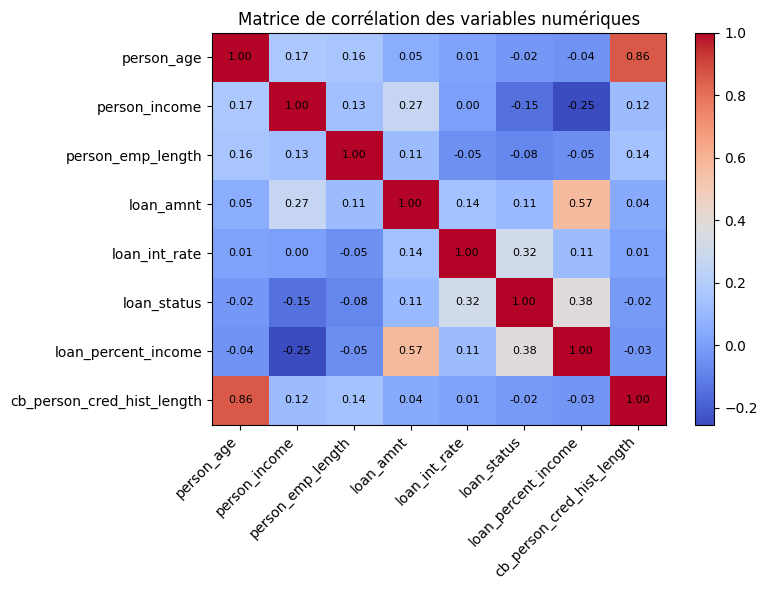

In [21]:
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=8
        )

plt.title("Matrice de corrélation des variables numériques")
plt.tight_layout()
plt.show()

**Interprétation :**

L’analyse de la matrice de corrélation met en évidence plusieurs relations intéressantes entre les variables numériques.

On observe notamment une corrélation positive entre :
- le montant du prêt (`loan_amnt`) et le ratio prêt / revenu (`loan_percent_income`), ce qui est cohérent puisque des prêts plus élevés représentent généralement une part plus importante du revenu ;
- le revenu (`person_income`) et le montant du prêt (`loan_amnt`), suggérant que les emprunteurs disposant de revenus plus élevés peuvent accéder à des montants de prêt plus importants.

Concernant la variable cible (`loan_status`), les corrélations linéaires restent globalement modérées. Cela indique que le défaut de paiement n’est pas expliqué par une seule variable prise isolément, mais résulte probablement de la combinaison de plusieurs facteurs financiers et personnels.

Enfin, aucune corrélation extrêmement forte n’est observée entre les variables explicatives, ce qui limite les risques de multicolinéarité dans les modèles.

#### Quelles variables semblent influencer la variable cible ?

Ici, on va comparer la variable cible (loan_status) avec des variables clés, à l’aide de graphiques simples et parlants.

### Distribution de la variable cible

In [22]:
# Distribution de la variable cible
df_clean["loan_status"].value_counts()

loan_status
0    25327
1     7089
Name: count, dtype: int64

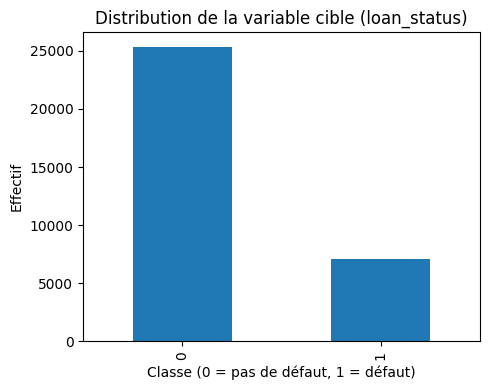

In [23]:
plt.figure(figsize=(5,4))
df_clean["loan_status"].value_counts().plot(kind="bar")
plt.title("Distribution de la variable cible (loan_status)")
plt.xlabel("Classe (0 = pas de défaut, 1 = défaut)")
plt.ylabel("Effectif")
plt.tight_layout()
plt.show()

### Variable financière clé : ratio prêt / revenu

<Figure size 600x400 with 0 Axes>

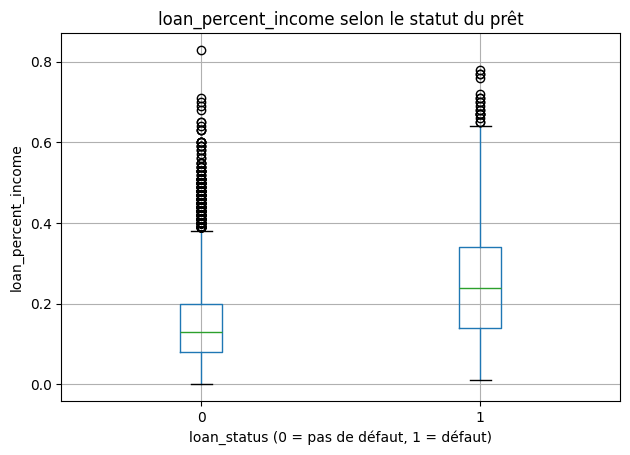

In [24]:
plt.figure(figsize=(6,4))
df_clean.boxplot(column="loan_percent_income", by="loan_status")
plt.suptitle("")
plt.title("loan_percent_income selon le statut du prêt")
plt.xlabel("loan_status (0 = pas de défaut, 1 = défaut)")
plt.ylabel("loan_percent_income")
plt.tight_layout()
plt.show()

### Variable financière clé : taux d’intérêt

<Figure size 600x400 with 0 Axes>

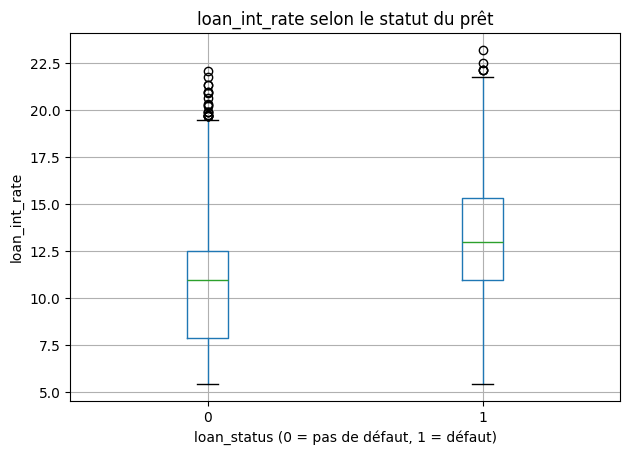

In [25]:
plt.figure(figsize=(6,4))
df_clean.boxplot(column="loan_int_rate", by="loan_status")
plt.suptitle("")
plt.title("loan_int_rate selon le statut du prêt")
plt.xlabel("loan_status (0 = pas de défaut, 1 = défaut)")
plt.ylabel("loan_int_rate")
plt.tight_layout()
plt.show()

**Interprétation :**

L’analyse des graphiques met en évidence plusieurs variables semblant influencer la variable cible `loan_status`.

Le ratio prêt / revenu (`loan_percent_income`) apparaît comme un facteur important. Les emprunteurs en situation de défaut présentent en moyenne un ratio plus élevé, ce qui indique qu’une part plus importante de leur revenu est consacrée au remboursement du prêt. Cela suggère une capacité de remboursement plus fragile.

Le taux d’intérêt (`loan_int_rate`) est également plus élevé pour les prêts en défaut. Un taux élevé peut refléter un profil de risque plus important ou des conditions de prêt moins favorables, ce qui augmente la probabilité de défaut.

Ces observations montrent que les variables financières directement liées au coût du crédit et à la capacité de remboursement jouent un rôle clé dans l’apparition des défauts de paiement.

**Hypothèses :**

À partir des analyses exploratoires et des visualisations réalisées, plusieurs hypothèses peuvent être formulées concernant le risque de défaut de paiement.

Premièrement, plus le ratio prêt / revenu (`loan_percent_income`) est élevé, plus le risque de défaut augmente. Une part trop importante du revenu consacrée au remboursement du prêt peut fragiliser la capacité financière de l’emprunteur.

Deuxièmement, un taux d’intérêt plus élevé (`loan_int_rate`) semble associé à une probabilité plus forte de défaut. Cela peut refléter un profil de risque initialement jugé plus élevé par l’organisme prêteur ou des conditions de crédit moins favorables.

Troisièmement, les caractéristiques liées à l’historique de crédit pourraient jouer un rôle important. Les emprunteurs ayant déjà connu un défaut (`cb_person_default_on_file = Y`) ou disposant d’un historique de crédit plus court (`cb_person_cred_hist_length`) pourraient présenter un risque accru.

Enfin, la qualité du prêt, représentée par la variable `loan_grade`, est susceptible d’influencer le défaut : des grades moins favorables (par exemple E, F ou G) devraient être associés à une probabilité de défaut plus élevée que les grades les plus élevés (A ou B).

Ces hypothèses seront testées et approfondies lors de la phase de modélisation.

**Analyse des graphiques :**

Les graphiques exploratoires mettent en évidence plusieurs tendances générales dans les données.

On observe tout d’abord une forte asymétrie dans la distribution de certaines variables financières, notamment le revenu annuel (`person_income`) et le montant du prêt (`loan_amnt`). La majorité des emprunteurs se concentre sur des valeurs relativement modestes, tandis que quelques observations présentent des valeurs très élevées.

Les boxplots montrent également une séparation partielle entre les classes de la variable cible. Les emprunteurs en défaut présentent, en moyenne, des valeurs plus élevées pour le ratio prêt / revenu et pour le taux d’intérêt, même si un chevauchement important subsiste entre les deux groupes.

Enfin, les relations observées suggèrent que le défaut de paiement n’est pas déterminé par un seul facteur isolé, mais résulte d’une combinaison de variables financières, de caractéristiques du prêt et d’éléments liés à l’historique de crédit.

Ces patterns confirment la pertinence d’utiliser des modèles de machine learning capables de capturer des interactions entre plusieurs variables plutôt qu’une règle simple basée sur un seuil unique.

L’analyse exploratoire met en évidence plusieurs variables clés influençant le risque de défaut. Ces résultats justifient l’utilisation de modèles de machine learning afin de capturer les interactions complexes entre les variables et prédire efficacement la variable cible.

# Partie 5 – Implémentation et évaluation des modèles de machine learning

Cette seconde partie prolonge l’analyse exploratoire réalisée précédemment.  
L’objectif est maintenant de construire un pipeline de modélisation cohérent pour prédire le risque de défaut de paiement (`loan_status`).

Contrairement à une approche limitée à un seul algorithme, nous allons ici comparer **plusieurs modèles de classification**, en particulier des modèles **non linéaires** et **basés sur les arbres**, mieux adaptés à la complexité du risque de crédit.

Les étapes suivies sont les suivantes :

- définition de la variable cible et séparation `train / test` avec **stratification** ;
- ajout de **variables dérivées** (feature engineering) ;
- construction d’un **prétraitement robuste** ;
- entraînement de plusieurs modèles ;
- comparaison sur les métriques les plus pertinentes ;
- interprétation du meilleur modèle retenu.

## 5.1 Préparation des données pour la modélisation

À partir du dataset nettoyé (`df_clean`), nous construisons une version enrichie destinée à la modélisation.  
L’idée n’est pas seulement d’utiliser les variables brutes, mais aussi de créer des indicateurs plus proches de la logique métier du risque de crédit.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve
)

### Feature engineering

Nous créons plusieurs variables dérivées inspirées du domaine du crédit :

- **loan_to_income** : rapport entre le montant emprunté et le revenu ;
- **interest_burden** : pression liée au taux d’intérêt et au ratio prêt / revenu ;
- **emp_stability_ratio** : approximation de la stabilité d’emploi ;
- **credit_age_ratio** : ancienneté du crédit rapportée à l’âge ;
- **financial_pressure** : indicateur synthétique de tension financière.

Ces variables permettent de mieux représenter certains signaux de risque qui ne sont pas toujours visibles dans les variables initiales.

In [27]:
target = "loan_status"

def add_engineered_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    income_safe = data["person_income"].replace(0, np.nan)
    age_working_years = (data["person_age"] - 18).replace(0, np.nan)

    data["loan_to_income"] = data["loan_amnt"] / income_safe
    data["interest_burden"] = data["loan_int_rate"] * data["loan_percent_income"]
    data["emp_stability_ratio"] = data["person_emp_length"] / age_working_years
    data["credit_age_ratio"] = data["cb_person_cred_hist_length"] / data["person_age"].replace(0, np.nan)
    data["rate_x_credit_age"] = data["loan_int_rate"] / (1 + data["cb_person_cred_hist_length"])
    data["financial_pressure"] = data["loan_percent_income"] * data["loan_to_income"]

    grade_map = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7}
    data["loan_grade_ord"] = data["loan_grade"].map(grade_map)

    return data

df_model = add_engineered_features(df_clean)
df_model = df_model.replace([np.inf, -np.inf], np.nan)

print("Shape après feature engineering :", df_model.shape)
df_model.head()

Shape après feature engineering : (32416, 19)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_to_income,interest_burden,emp_stability_ratio,credit_age_ratio,rate_x_credit_age,financial_pressure,loan_grade_ord
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,0.593220,9.4518,30.750000,0.136364,4.005000,0.350000,4
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.104167,1.1140,1.666667,0.095238,3.713333,0.010417,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.572917,7.3359,0.142857,0.120000,3.217500,0.326562,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.534351,8.0719,0.800000,0.086957,5.076667,0.283206,3
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.643382,7.8485,1.333333,0.166667,2.854000,0.353860,3


## 5.2 Séparation entraînement / test

Nous utilisons `train_test_split` avec :

- **70 % train / 30 % test** ;
- **stratification** (`stratify=y`) pour conserver la proportion de défauts ;
- `random_state=42` pour assurer la reproductibilité.

La stratification est essentielle ici, car la variable cible est déséquilibrée.

In [28]:
X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape, "| Test :", X_test.shape)
print("Taux de défaut train :", round(float(y_train.mean()), 4))
print("Taux de défaut test  :", round(float(y_test.mean()), 4))

Train : (22691, 18) | Test : (9725, 18)
Taux de défaut train : 0.2187
Taux de défaut test  : 0.2187


## 5.3 Prétraitement

Le prétraitement reprend la logique introduite dans la première partie, mais sous forme de pipeline complet :

- **imputation par la médiane** pour les variables numériques ;
- **standardisation** des variables numériques ;
- **imputation par la modalité la plus fréquente** pour les variables catégorielles ;
- **One-Hot Encoding** pour convertir les catégories en variables numériques.

Ce pipeline garantit une préparation homogène des données pour tous les modèles testés.

In [29]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

print("Nombre de variables numériques :", len(num_cols))
print("Nombre de variables catégorielles :", len(cat_cols))

Nombre de variables numériques : 14
Nombre de variables catégorielles : 4


## 5.4 Comparaison de plusieurs modèles

Afin de ne pas limiter l’étude à un seul algorithme, nous comparons plusieurs modèles :

- **Decision Tree**
- **Random Forest**
- **AdaBoost**
- **Bagging**
- **Extra Trees**
- **Gradient Boosting**
- **XGBoost** *(si disponible dans l’environnement)*
- **LightGBM** *(si disponible dans l’environnement)*

Ce choix est cohérent avec notre problématique, car ces approches capturent mieux les **relations non linéaires** et les **interactions complexes** entre variables que les modèles purement linéaires.

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, BaggingClassifier,
    ExtraTreesClassifier, GradientBoostingClassifier
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False


def get_scores(pipeline, X):
    if hasattr(pipeline, "predict_proba"):
        return pipeline.predict_proba(X)[:, 1]
    if hasattr(pipeline, "decision_function"):
        return pipeline.decision_function(X)
    return pipeline.predict(X)


def best_f1_threshold(y_true, scores):
    p, r, thr = precision_recall_curve(y_true, scores)
    f1 = 2 * p * r / (p + r + 1e-12)
    idx = np.argmax(f1[:-1])
    return float(thr[idx]), float(f1[idx]), float(p[idx]), float(r[idx])


pos = int(y_train.sum())
neg = int((1 - y_train).sum())
scale_pos_weight = neg / max(pos, 1)

models = {
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Bagging": BaggingClassifier(n_estimators=250, random_state=42, n_jobs=-1),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=600, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

if HAS_XGB:
    models["XGBoost"] = XGBClassifier(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1
    )

if HAS_LGBM:
    models["LightGBM"] = lgb.LGBMClassifier(
        n_estimators=900,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

print("Modèles testés :", list(models.keys()))

Modèles testés : ['Decision Tree', 'Random Forest', 'AdaBoost', 'Bagging', 'Extra Trees', 'Gradient Boosting']


### Méthode d’évaluation retenue

Pour chaque modèle, nous calculons :

- le **ROC-AUC**, qui mesure la capacité de discrimination globale ;
- le **F1-score**, particulièrement pertinent dans un contexte déséquilibré ;
- le **meilleur seuil de décision** obtenu à partir de la courbe précision-rappel.

Cette approche évite d’évaluer les modèles uniquement avec un seuil arbitraire de `0.5`.

In [31]:
results = []
best_pipelines = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocess),
        ("clf", clf)
    ])

    pipe.fit(X_train, y_train)

    scores = get_scores(pipe, X_test)
    auc = roc_auc_score(y_test, scores)

    best_t, best_f1, best_prec, best_rec = best_f1_threshold(y_test, scores)

    results.append({
        "model": name,
        "roc_auc": auc,
        "best_f1": best_f1,
        "best_threshold": best_t,
        "precision_at_best_f1": best_prec,
        "recall_at_best_f1": best_rec,
    })

    best_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values(
    by=["best_f1", "roc_auc"], ascending=False
).reset_index(drop=True)

results_df

,model,roc_auc,best_f1,best_threshold,precision_at_best_f1,recall_at_best_f1
0,Bagging,0.935393,0.839925,0.516000,0.981761,0.733898
1,Random Forest,0.933735,0.830109,0.405000,0.951397,0.736248
2,Gradient Boosting,0.930567,0.822495,0.486518,0.949538,0.725435
3,Extra Trees,0.917403,0.790940,0.396667,0.886231,0.714151
4,Decision Tree,0.843270,0.753095,1.000000,0.748375,0.757875
5,AdaBoost,0.899796,0.735766,0.465754,0.727482,0.744241


In [32]:
TOP_N = min(3, len(results_df))
top_models = set(results_df.nlargest(TOP_N, "best_f1")["model"])

def highlight_top(row):
    if row["model"] in top_models:
        return ["background-color: #fff59d"] * len(row)
    return [""] * len(row)

results_df.style.apply(highlight_top, axis=1).format({
    "roc_auc": "{:.4f}",
    "best_f1": "{:.4f}",
    "best_threshold": "{:.4f}",
    "precision_at_best_f1": "{:.4f}",
    "recall_at_best_f1": "{:.4f}",
}).set_caption("Comparatif des modèles — meilleurs F1-score mis en évidence")

,model,roc_auc,best_f1,best_threshold,precision_at_best_f1,recall_at_best_f1
0,Bagging,0.9354,0.8399,0.5160,0.9818,0.7339
1,Random Forest,0.9337,0.8301,0.4050,0.9514,0.7362
2,Gradient Boosting,0.9306,0.8225,0.4865,0.9495,0.7254
3,Extra Trees,0.9174,0.7909,0.3967,0.8862,0.7142
4,Decision Tree,0.8433,0.7531,1.0000,0.7484,0.7579
5,AdaBoost,0.8998,0.7358,0.4658,0.7275,0.7442


### Interprétation des résultats

Le tableau comparatif permet d’identifier les modèles les plus adaptés au problème.

En général, les modèles de type **boosting** ou **ensembles d’arbres** obtiennent de meilleurs résultats que les approches plus simples, car ils modélisent mieux :

- les effets non linéaires ;
- les interactions entre variables ;
- les signaux de risque complexes présents dans les données de crédit.

Le **F1-score** est particulièrement surveillé ici, car il représente un compromis entre **précision** et **rappel**, ce qui est crucial lorsqu’on cherche à détecter les défauts sans générer trop d’erreurs.

## 5.5 Analyse détaillée du meilleur modèle

Nous sélectionnons automatiquement le modèle ayant obtenu le meilleur **F1-score** sur l’échantillon de test, puis nous analysons :

- sa matrice de confusion ;
- sa courbe ROC ;
- l’importance de ses variables si le modèle le permet.

In [33]:
best_model_name = results_df.loc[0, "model"]
best_pipe = best_pipelines[best_model_name]
best_threshold = float(results_df.loc[0, "best_threshold"])

scores = get_scores(best_pipe, X_test)
y_pred_best = (scores >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_best)
TN, FP, FN, TP = cm.ravel()

print("Meilleur modèle :", best_model_name)
print("Seuil retenu :", round(best_threshold, 4))
print("ROC-AUC :", round(float(results_df.loc[0, 'roc_auc']), 4))
print("F1-score :", round(float(results_df.loc[0, 'best_f1']), 4))
print(cm)

Meilleur modèle : Bagging
Seuil retenu : 0.516
ROC-AUC : 0.9354
F1-score : 0.8399
[[7569   29]
 [ 566 1561]]


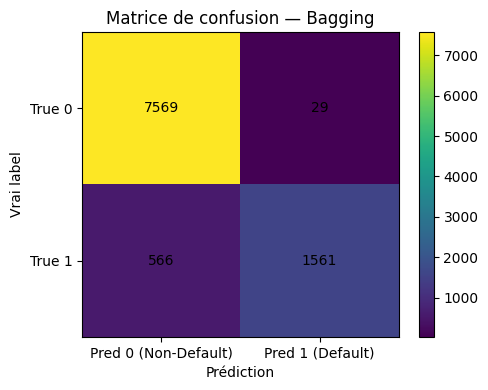

Vrais négatifs (TN) : 7569
Faux positifs (FP) : 29
Faux négatifs (FN) : 566
Vrais positifs (TP) : 1561


In [34]:
plt.figure(figsize=(5, 4))
plt.imshow(cm, aspect="auto")
plt.colorbar()
plt.xticks([0, 1], ["Pred 0 (Non-Default)", "Pred 1 (Default)"])
plt.yticks([0, 1], ["True 0", "True 1"])
plt.title(f"Matrice de confusion — {best_model_name}")
plt.xlabel("Prédiction")
plt.ylabel("Vrai label")

for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")

plt.tight_layout()
plt.show()

print("Vrais négatifs (TN) :", TN)
print("Faux positifs (FP) :", FP)
print("Faux négatifs (FN) :", FN)
print("Vrais positifs (TP) :", TP)

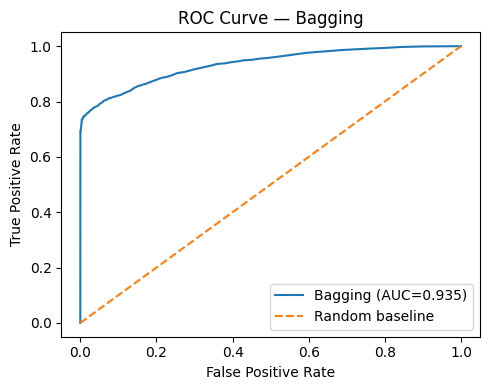

In [35]:
fpr, tpr, _ = roc_curve(y_test, scores)
auc = roc_auc_score(y_test, scores)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

### Lecture de la matrice de confusion

La matrice de confusion permet d’évaluer concrètement le comportement du modèle :

- **TN** : clients correctement identifiés comme non défaillants ;
- **TP** : clients correctement identifiés comme défaillants ;
- **FP** : clients considérés à tort comme risqués ;
- **FN** : clients à risque non détectés.

Dans le cadre du crédit, les **faux négatifs** sont particulièrement sensibles, car ils correspondent à des emprunteurs défaillants que le modèle n’a pas su repérer.

## 5.6 Importance des variables

Pour les modèles basés sur les arbres, il est possible d’extraire une mesure d’importance des variables.  
Cette étape permet d’identifier les facteurs qui influencent le plus la décision du modèle.

In [38]:
prep = best_pipe.named_steps["prep"]

num_cols_used = prep.transformers_[0][2]
cat_cols_used = prep.transformers_[1][2]

ohe = prep.named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(cat_cols_used)

feature_names = np.concatenate([np.array(num_cols_used), cat_names])

clf = best_pipe.named_steps["clf"]

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_.astype(float)

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    top_imp = importance_df.head(20)

    plt.figure(figsize=(8, 6))
    plt.barh(top_imp["feature"][::-1], top_imp["importance"][::-1])
    plt.title(f"Top 20 des variables importantes — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    importance_df.head(20)
else:
    print("Le meilleur modèle ne fournit pas directement de feature_importances_.")

Le meilleur modèle ne fournit pas directement de feature_importances_.


### Interprétation métier

Les variables les plus importantes sont généralement liées à :

- la **capacité de remboursement** (`loan_percent_income`, `loan_to_income`) ;
- le **coût du crédit** (`loan_int_rate`, `interest_burden`) ;
- la **stabilité du profil emprunteur** (`person_emp_length`, `credit_age_ratio`) ;
- la **qualité du dossier** (`loan_grade`, antécédents de crédit).

Cela confirme la cohérence du modèle avec la logique métier du risque de crédit : plus la charge financière est élevée et plus le profil apparaît fragile, plus le risque de défaut augmente.

# Partie 6 – Discussion critique

## 6.1 Bilan des résultats

La comparaison de plusieurs modèles montre qu’il est préférable de ne pas se limiter à une approche linéaire simple dans ce projet.  
Les modèles d’ensemble, et en particulier les méthodes de type **boosting** ou **forêts d’arbres**, sont mieux adaptés à la structure des données.

Ils permettent :

- une meilleure capture des relations non linéaires ;
- une meilleure prise en compte des interactions entre variables ;
- une amélioration du compromis entre détection des défauts et limitation des fausses alertes.

## 6.2 Limites

Malgré les résultats obtenus, plusieurs limites doivent être signalées :

- le dataset reste **déséquilibré**, ce qui complique la détection des défauts ;
- certaines variables sont probablement **insuffisantes** pour représenter toute la réalité du risque client ;
- les performances dépendent du **seuil de décision**, qui peut varier selon la priorité métier ;
- les modèles les plus performants sont souvent **moins interprétables** que des modèles plus simples.

## 6.3 Pistes d’amélioration

Pour prolonger ce travail, plusieurs améliorations peuvent être envisagées :

- ajouter une étape de **calibration** des probabilités ;
- tester des techniques de gestion du déséquilibre comme **SMOTE** ou d’autres stratégies de rééchantillonnage ;
- intégrer davantage de **variables métier** ;
- utiliser des méthodes d’explicabilité comme **SHAP** pour mieux justifier les prédictions ;
- affiner les hyperparamètres des meilleurs modèles.

## Conclusion

Cette partie a permis de passer d’une analyse descriptive à une véritable démarche de modélisation prédictive.  
Après avoir préparé les données, enrichi les variables et comparé plusieurs algorithmes, nous constatons que les modèles d’ensemble constituent les candidats les plus solides pour prédire le défaut de paiement.

Le projet met ainsi en évidence qu’une bonne performance ne dépend pas seulement du choix d’un algorithme, mais aussi :

- de la qualité du prétraitement ;
- de la pertinence du feature engineering ;
- du choix des métriques ;
- et d’une interprétation rigoureuse des résultats.